# Superstore Sales & Profit Analysis
## Complete Data Visualization & EDA Project

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

This notebook is a complete, defensive version of the Superstore data-visualization project. It standardizes column names once and checks for empty datasets before creating visualizations.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")


## 2. Load Dataset

In [2]:
# Works both locally and after putting the CSV inside a GitHub project.
possible_files = [
    Path("data") / "SampleSuperstore.csv",
    Path("SampleSuperstore.csv"),
    Path.home() / "Downloads" / "SampleSuperstore.csv",
    Path.home() / "Downloads" / "SampleSuperstore.csv" / "SampleSuperstore.csv",
]

data_file = next((p for p in possible_files if p.is_file()), None)

if data_file is None:
    candidates = [p for p in Path.cwd().rglob("SampleSuperstore.csv") if p.is_file()]
    data_file = candidates[0] if candidates else None

if data_file is None:
    raise FileNotFoundError(
        "SampleSuperstore.csv not found. Put the CSV in a 'data' folder "
        "or in the same folder as this notebook."
    )

df = pd.read_csv(data_file, encoding="latin1")

print(f"Dataset loaded: {data_file}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())


Dataset loaded: C:\Users\Dell\Downloads\SampleSuperstore.csv\SampleSuperstore.csv
Rows: 9,994
Columns: 13


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.00,41.91
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3,0.00,219.58
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2,0.00,6.87
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5,0.45,-383.03
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.37,2,0.20,2.52


## 3. Inspect and Standardize Columns

In [3]:
print("Original columns:")
print(df.columns.tolist())

df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.replace("-", "_", regex=False)
      .str.replace(" ", "_", regex=False)
      .str.lower()
)

print("\nStandardized columns:")
print(df.columns.tolist())


Original columns:
['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']

Standardized columns:
['ship_mode', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'category', 'sub_category', 'sales', 'quantity', 'discount', 'profit']


## 4. Validate Required Columns

In [4]:
required_columns = [
    "sales", "quantity", "discount", "profit",
    "category", "sub_category", "region",
    "state", "city", "segment", "ship_mode"
]

missing = [c for c in required_columns if c not in df.columns]

if missing:
    raise ValueError(
        f"Required columns are missing: {missing}\n"
        f"Available columns: {df.columns.tolist()}"
    )

print("All required analytical columns are available.")


All required analytical columns are available.


## 5. Data Cleaning & Quality Checks

In [5]:
numeric_columns = ["sales", "quantity", "discount", "profit"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

text_columns = [
    "category", "sub_category", "region",
    "state", "city", "segment", "ship_mode"
]

for col in text_columns:
    df[col] = df[col].astype("string").str.strip()

print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("Duplicate rows:", df.duplicated().sum())

before = len(df)
df = df.dropna(subset=numeric_columns + ["category", "sub_category"])
print(f"Rows removed due to missing required values: {before - len(df):,}")
print(f"Final rows: {len(df):,}")


Missing values:


ship_mode       0
segment         0
country         0
city            0
state           0
postal_code     0
region          0
category        0
sub_category    0
sales           0
quantity        0
discount        0
profit          0
dtype: int64

Duplicate rows: 17
Rows removed due to missing required values: 0
Final rows: 9,994


## 6. Descriptive Statistics

In [6]:
display(df[numeric_columns].describe().T)


,count,mean,std,min,25%,50%,75%,max
sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48"
quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00
discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98"


## 7. KPI Summary

In [7]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_quantity = df["quantity"].sum()
avg_discount = df["discount"].mean()
profit_margin = (total_profit / total_sales * 100) if total_sales else np.nan

kpi = pd.DataFrame({
    "Metric": ["Total Sales", "Total Profit", "Total Quantity", "Average Discount", "Profit Margin"],
    "Value": [total_sales, total_profit, total_quantity, avg_discount, profit_margin]
})
display(kpi)


,Metric,Value
0,Total Sales,"2,297,200.86"
1,Total Profit,"286,397.02"
2,Total Quantity,"37,873.00"
3,Average Discount,0.16
4,Profit Margin,12.47


# Exploratory Data Visualization

## 8. Sales Distribution

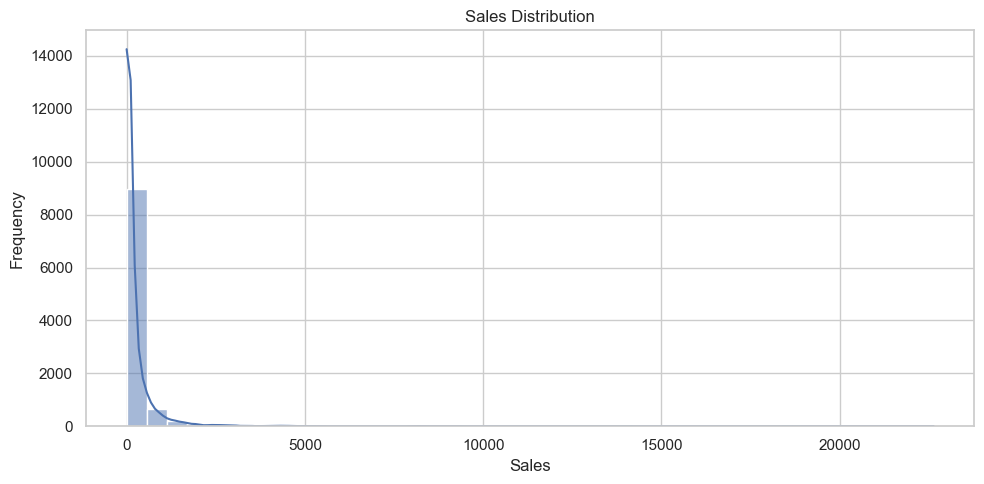

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df["sales"], bins=40, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 9. Profit Distribution

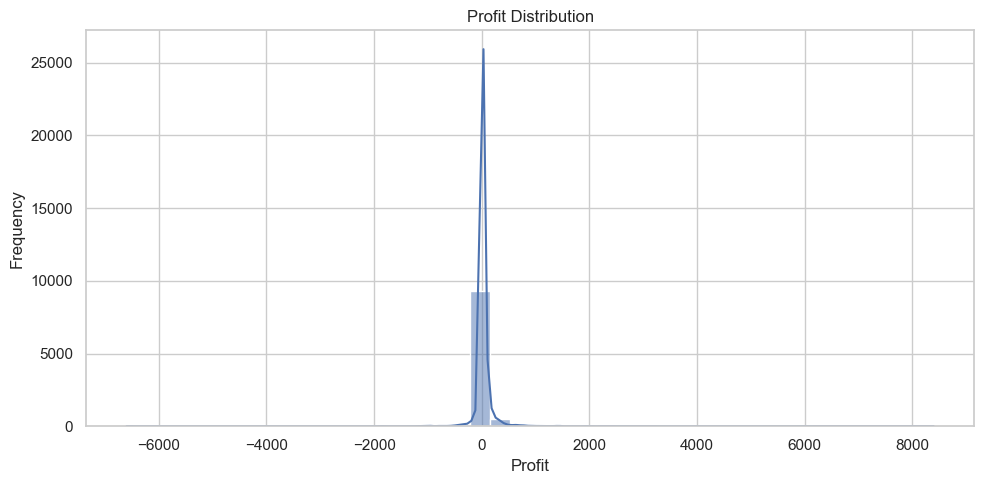

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df["profit"], bins=40, kde=True)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 10. Quantity Distribution

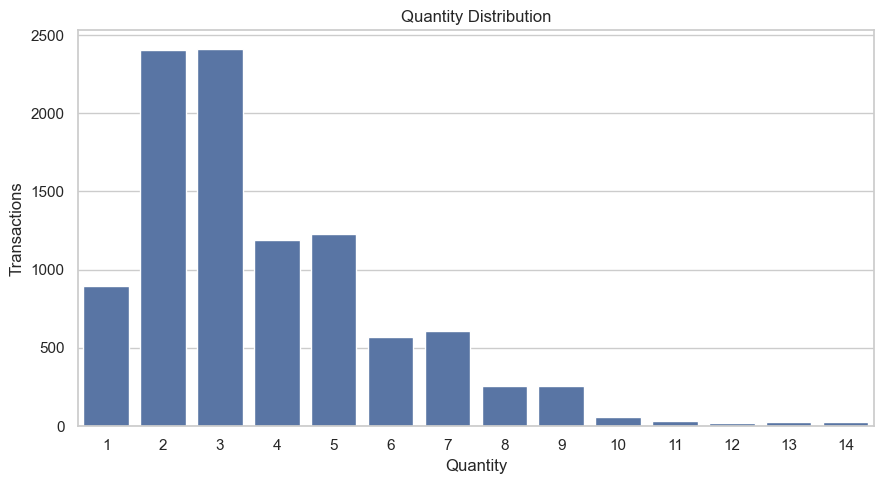

In [10]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="quantity")
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Transactions")
plt.tight_layout()
plt.show()


## 11. Sales by Category

,category,sales
2,Technology,"836,154.03"
0,Furniture,"741,999.80"
1,Office Supplies,"719,047.03"


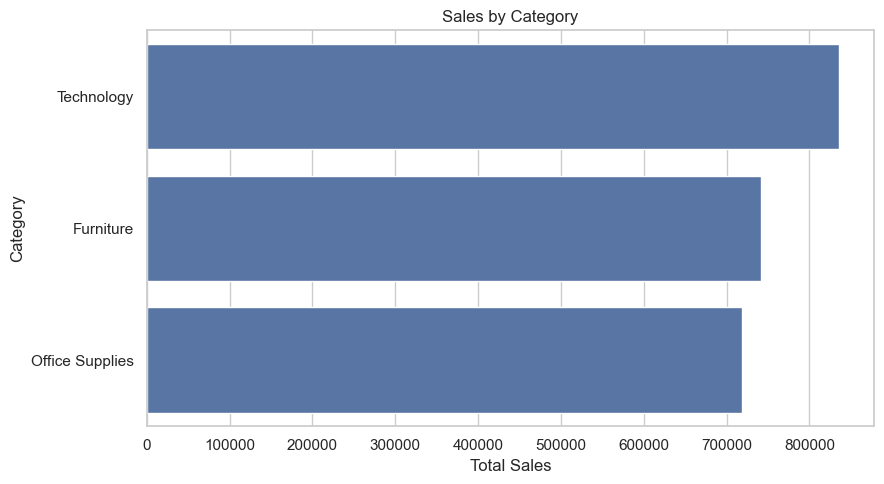

In [11]:
category_sales = (
    df.groupby("category", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=False)
)
display(category_sales)

plt.figure(figsize=(9, 5))
sns.barplot(data=category_sales, x="sales", y="category")
plt.title("Sales by Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


## 12. Profit by Category

,category,profit
2,Technology,"145,454.95"
1,Office Supplies,"122,490.80"
0,Furniture,"18,451.27"


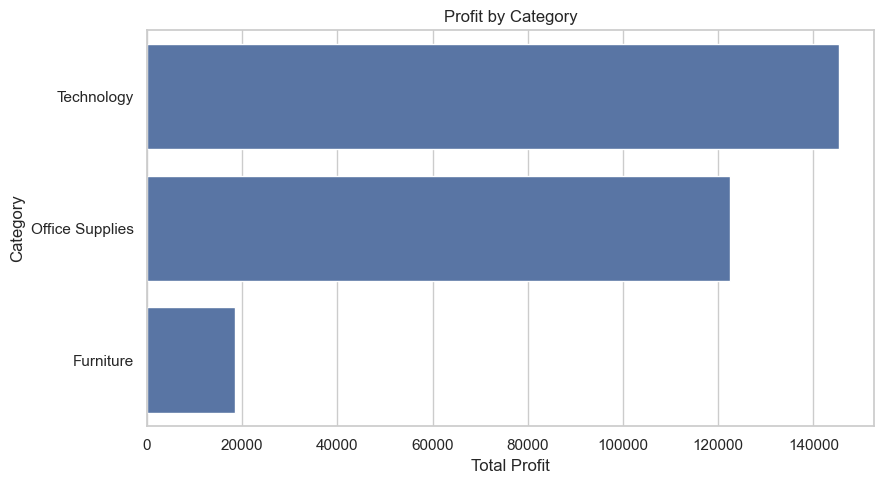

In [12]:
category_profit = (
    df.groupby("category", as_index=False)["profit"]
      .sum()
      .sort_values("profit", ascending=False)
)
display(category_profit)

plt.figure(figsize=(9, 5))
sns.barplot(data=category_profit, x="profit", y="category")
plt.title("Profit by Category")
plt.xlabel("Total Profit")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


## 13. Category Sales vs Profit

,category,sales,profit
0,Furniture,"741,999.80","18,451.27"
1,Office Supplies,"719,047.03","122,490.80"
2,Technology,"836,154.03","145,454.95"


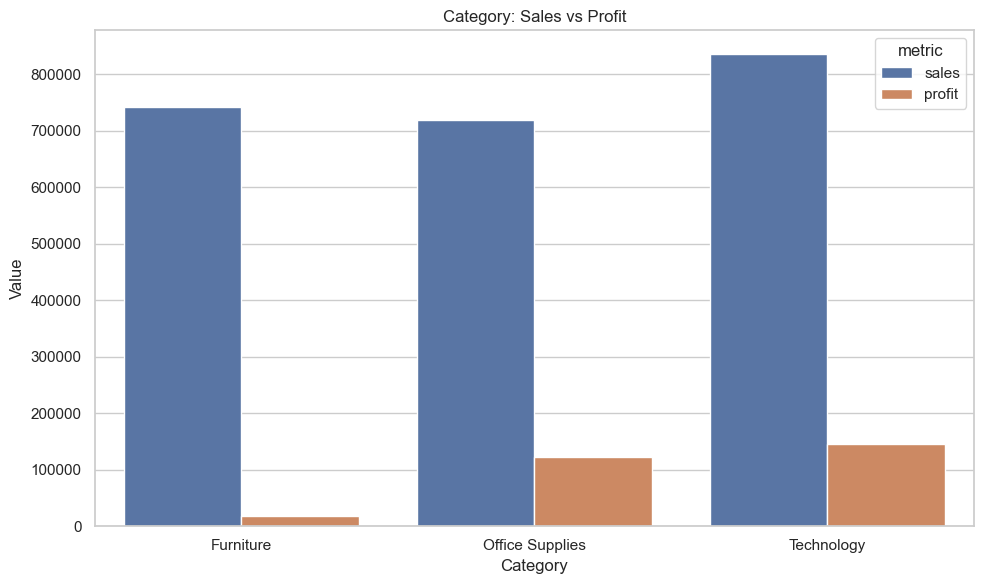

In [13]:
category_performance = (
    df.groupby("category", as_index=False)
      .agg(sales=("sales", "sum"), profit=("profit", "sum"))
)
display(category_performance)

plot_data = category_performance.melt(
    id_vars="category", value_vars=["sales", "profit"],
    var_name="metric", value_name="value"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x="category", y="value", hue="metric")
plt.title("Category: Sales vs Profit")
plt.xlabel("Category")
plt.ylabel("Value")
plt.tight_layout()
plt.show()


## 14. Top 10 Sub-Categories by Sales

,sub_category,sales
13,Phones,"330,007.05"
5,Chairs,"328,449.10"
14,Storage,"223,843.61"
16,Tables,"206,965.53"
3,Binders,"203,412.73"
11,Machines,"189,238.63"
0,Accessories,"167,380.32"
6,Copiers,"149,528.03"
4,Bookcases,"114,880.00"
1,Appliances,"107,532.16"


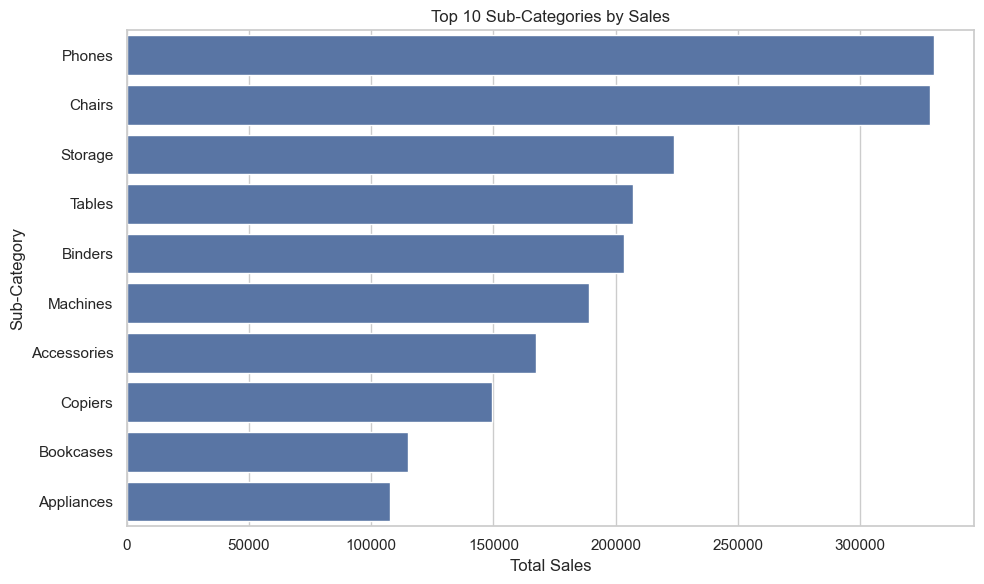

In [14]:
subcategory_sales = (
    df.groupby("sub_category", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=False)
)
top_subcategories = subcategory_sales.head(10)
display(top_subcategories)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_subcategories, x="sales", y="sub_category")
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


## 15. Profit by Sub-Category

,sub_category,total_sales,total_profit
6,Copiers,"149,528.03","55,617.82"
13,Phones,"330,007.05","44,515.73"
0,Accessories,"167,380.32","41,936.64"
12,Paper,"78,479.21","34,053.57"
3,Binders,"203,412.73","30,221.76"
5,Chairs,"328,449.10","26,590.17"
14,Storage,"223,843.61","21,278.83"
1,Appliances,"107,532.16","18,138.01"
9,Furnishings,"91,705.16","13,059.14"
7,Envelopes,"16,476.40","6,964.18"


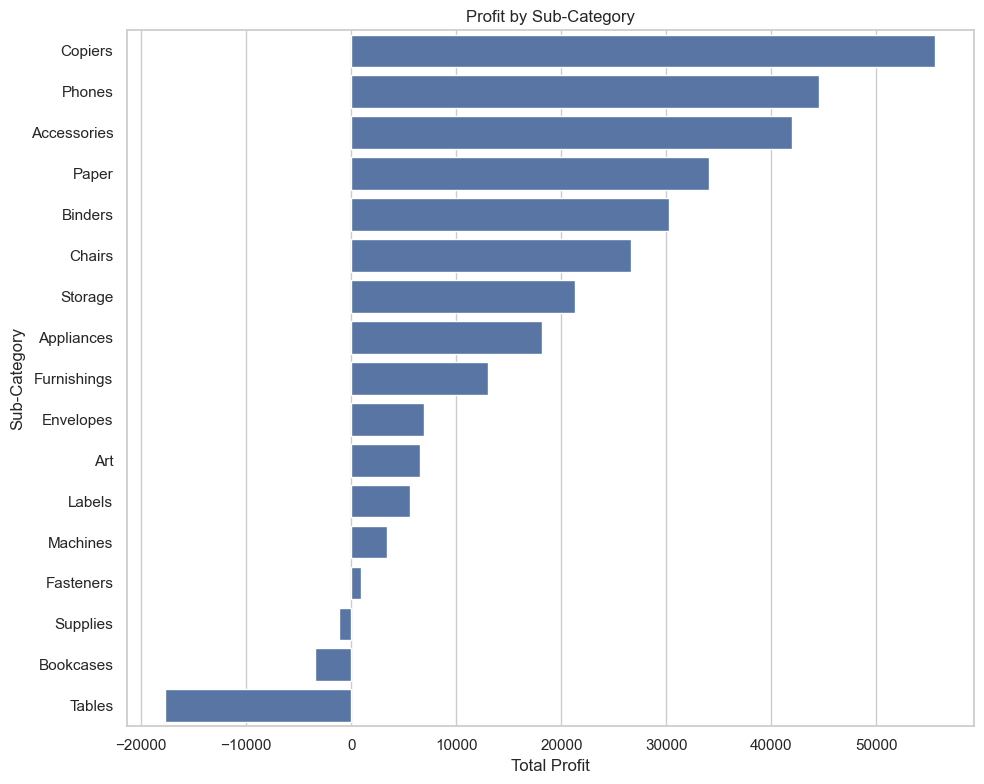

In [15]:
subcategory_profit = (
    df.groupby("sub_category", as_index=False)
      .agg(total_sales=("sales", "sum"), total_profit=("profit", "sum"))
      .sort_values("total_profit", ascending=False)
)
display(subcategory_profit)

plt.figure(figsize=(10, 8))
sns.barplot(data=subcategory_profit, x="total_profit", y="sub_category")
plt.title("Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


## 16. Loss-Making Sub-Categories

Loss-making sub-categories: 3


,sub_category,total_sales,total_profit
15,Supplies,"46,673.54","-1,189.10"
4,Bookcases,"114,880.00","-3,472.56"
16,Tables,"206,965.53","-17,725.48"


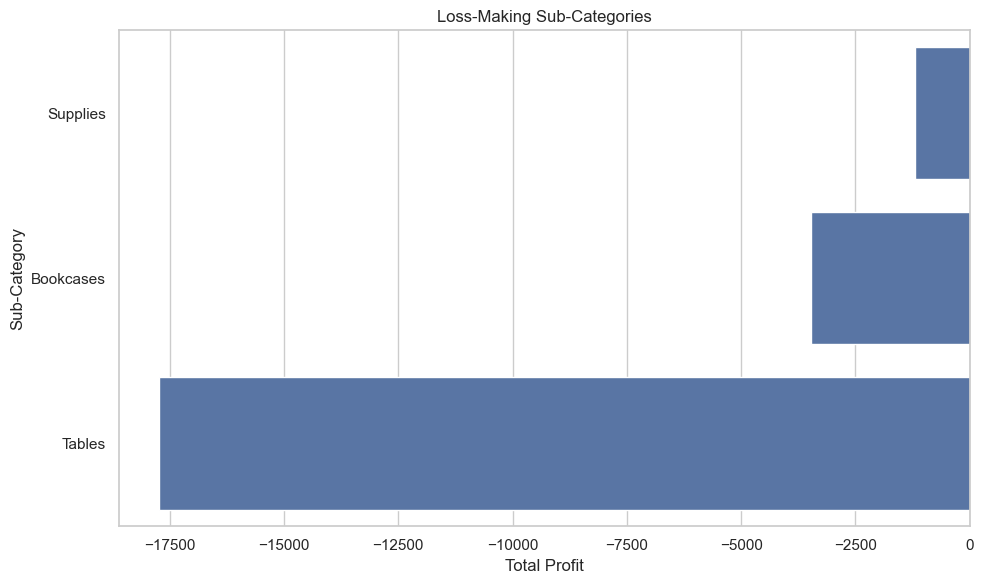

In [16]:
loss_subcategories = subcategory_profit[
    subcategory_profit["total_profit"] < 0
].copy()

print(f"Loss-making sub-categories: {len(loss_subcategories)}")

if loss_subcategories.empty:
    print("No sub-category has an overall negative profit.")
else:
    display(loss_subcategories)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=loss_subcategories, x="total_profit", y="sub_category")
    plt.title("Loss-Making Sub-Categories")
    plt.xlabel("Total Profit")
    plt.ylabel("Sub-Category")
    plt.tight_layout()
    plt.show()


## 17. Regional Sales

,region,sales
3,West,"725,457.82"
1,East,"678,781.24"
0,Central,"501,239.89"
2,South,"391,721.91"


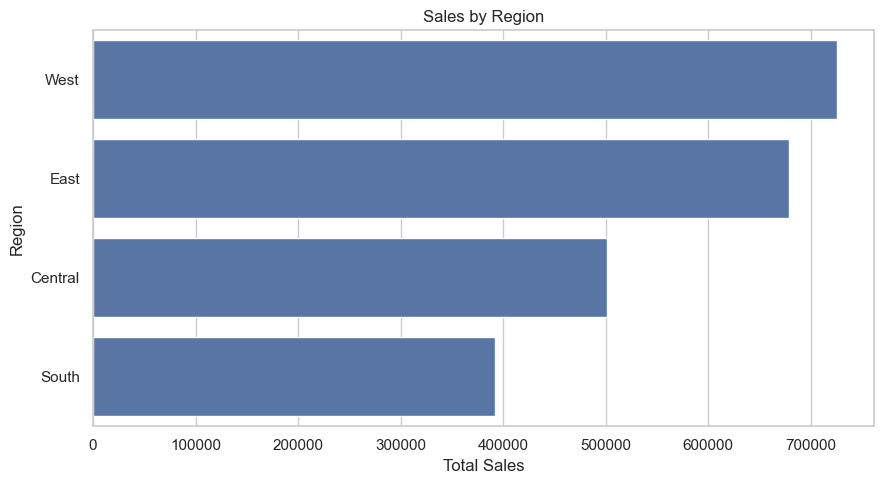

In [17]:
region_sales = (
    df.groupby("region", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=False)
)
display(region_sales)

plt.figure(figsize=(9, 5))
sns.barplot(data=region_sales, x="sales", y="region")
plt.title("Sales by Region")
plt.xlabel("Total Sales")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


## 18. Regional Profit

,region,profit
3,West,"108,418.45"
1,East,"91,522.78"
2,South,"46,749.43"
0,Central,"39,706.36"


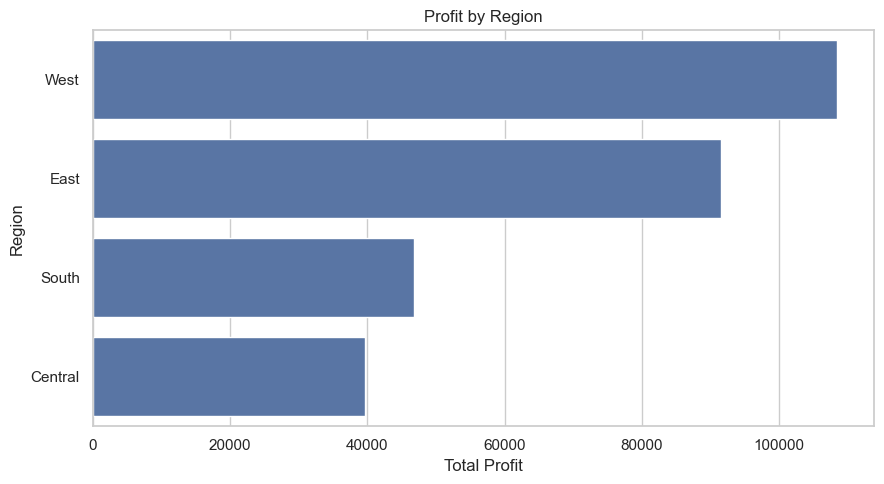

In [18]:
region_profit = (
    df.groupby("region", as_index=False)["profit"]
      .sum()
      .sort_values("profit", ascending=False)
)
display(region_profit)

plt.figure(figsize=(9, 5))
sns.barplot(data=region_profit, x="profit", y="region")
plt.title("Profit by Region")
plt.xlabel("Total Profit")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


## 19. Customer Segment Performance

,segment,sales,profit,quantity
0,Consumer,"1,161,401.34","134,119.21",19521
1,Corporate,"706,146.37","91,979.13",11608
2,Home Office,"429,653.15","60,298.68",6744


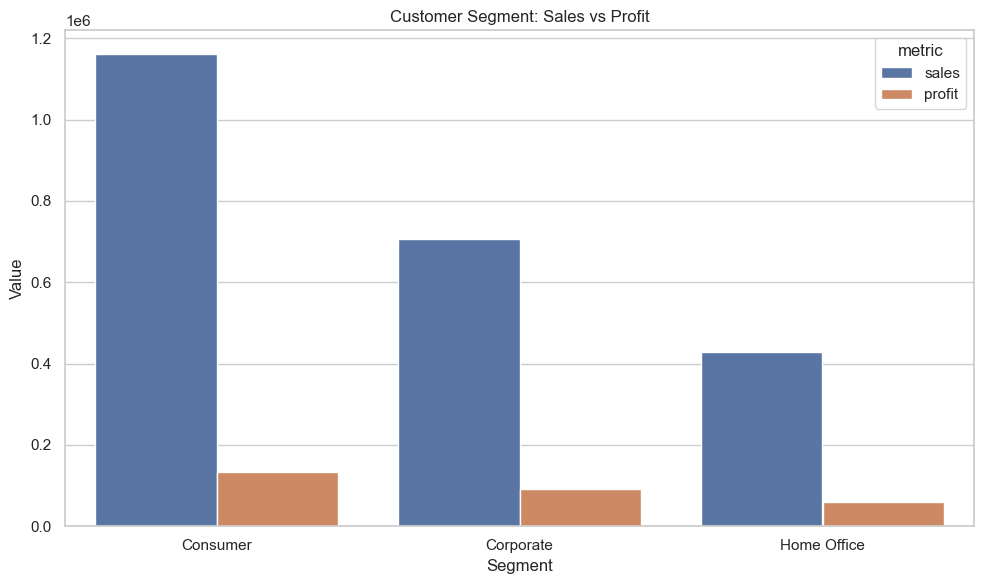

In [19]:
segment_performance = (
    df.groupby("segment", as_index=False)
      .agg(sales=("sales", "sum"), profit=("profit", "sum"), quantity=("quantity", "sum"))
)
display(segment_performance)

plot_segment = segment_performance.melt(
    id_vars="segment", value_vars=["sales", "profit"],
    var_name="metric", value_name="value"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_segment, x="segment", y="value", hue="metric")
plt.title("Customer Segment: Sales vs Profit")
plt.xlabel("Segment")
plt.ylabel("Value")
plt.tight_layout()
plt.show()


## 20. Ship Mode Performance

,ship_mode,sales,profit
0,First Class,"351,428.42","48,969.84"
1,Same Day,"128,363.12","15,891.76"
2,Second Class,"459,193.57","57,446.64"
3,Standard Class,"1,358,215.74","164,088.79"


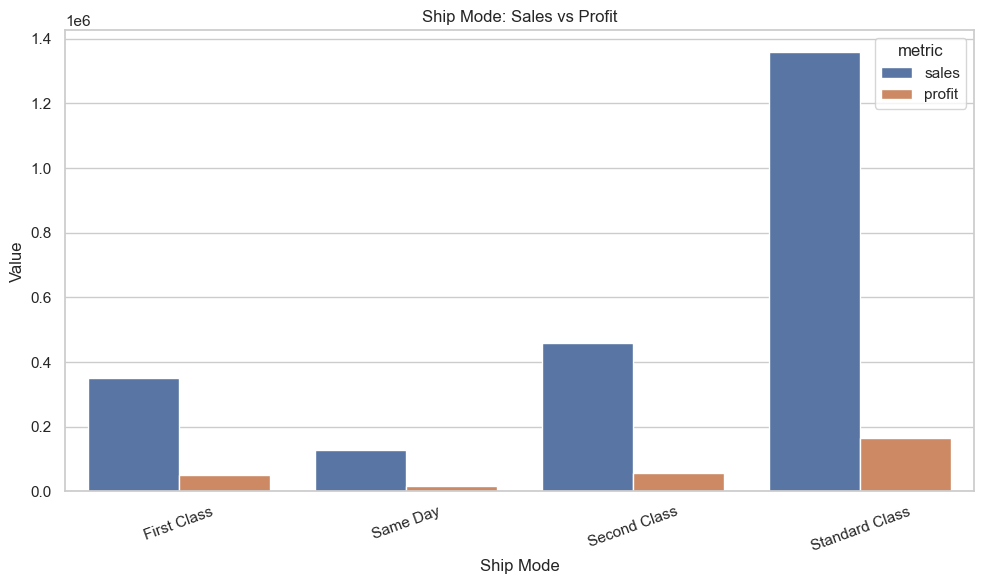

In [20]:
ship_performance = (
    df.groupby("ship_mode", as_index=False)
      .agg(sales=("sales", "sum"), profit=("profit", "sum"))
)
display(ship_performance)

plot_ship = ship_performance.melt(
    id_vars="ship_mode", value_vars=["sales", "profit"],
    var_name="metric", value_name="value"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_ship, x="ship_mode", y="value", hue="metric")
plt.title("Ship Mode: Sales vs Profit")
plt.xlabel("Ship Mode")
plt.ylabel("Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 21. Top 15 States by Sales

,state,sales
3,California,"457,687.63"
30,New York,"310,876.27"
41,Texas,"170,188.05"
45,Washington,"138,641.27"
36,Pennsylvania,"116,511.91"
8,Florida,"89,473.71"
11,Illinois,"80,166.10"
33,Ohio,"78,258.14"
20,Michigan,"76,269.61"
44,Virginia,"70,636.72"


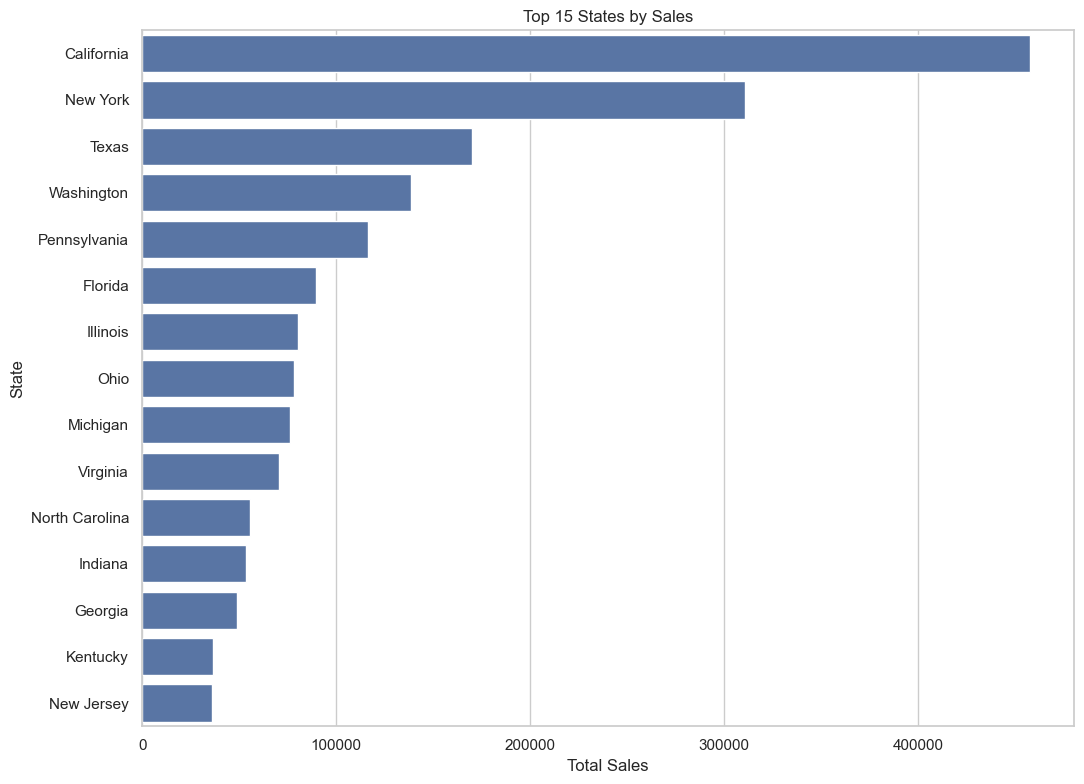

In [21]:
state_sales = (
    df.groupby("state", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=False)
)
display(state_sales.head(15))

plt.figure(figsize=(11, 8))
sns.barplot(data=state_sales.head(15), x="sales", y="state")
plt.title("Top 15 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.tight_layout()
plt.show()


## 22. Top 15 States by Profit

,state,profit
3,California,"76,381.39"
30,New York,"74,038.55"
45,Washington,"33,402.65"
20,Michigan,"24,463.19"
44,Virginia,"18,597.95"
12,Indiana,"18,382.94"
9,Georgia,"16,250.04"
15,Kentucky,"11,199.70"
21,Minnesota,"10,823.19"
6,Delaware,"9,977.37"


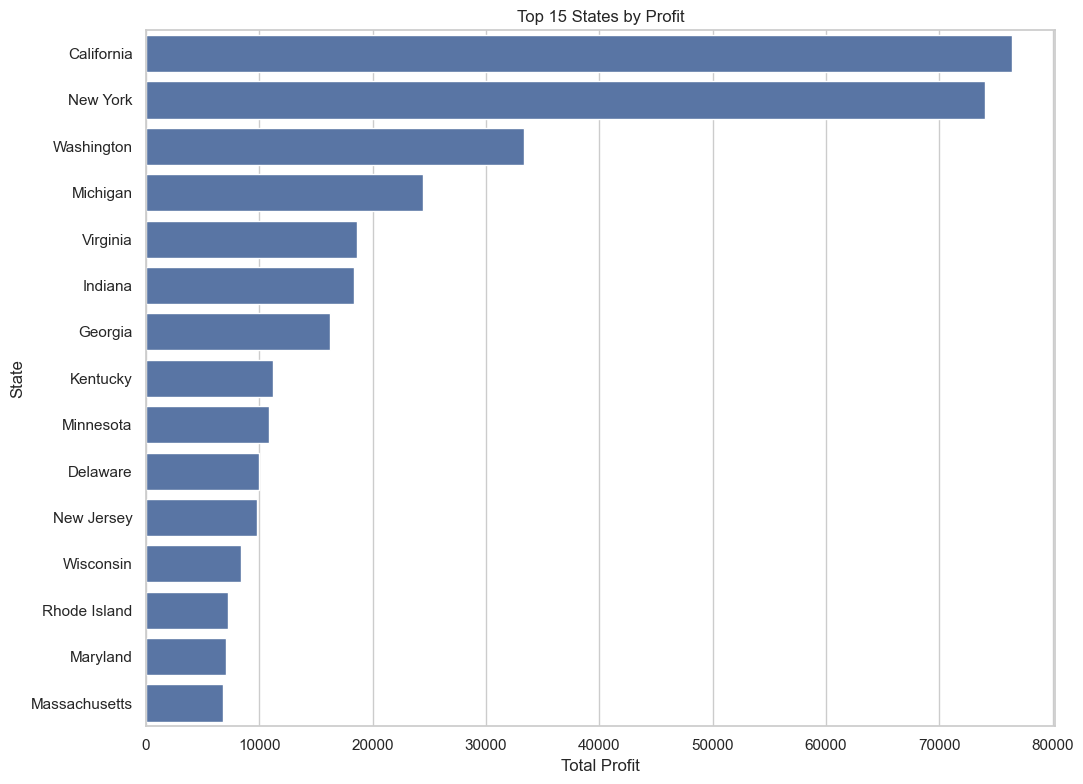

In [22]:
state_profit = (
    df.groupby("state", as_index=False)["profit"]
      .sum()
      .sort_values("profit", ascending=False)
)
display(state_profit.head(15))

plt.figure(figsize=(11, 8))
sns.barplot(data=state_profit.head(15), x="profit", y="state")
plt.title("Top 15 States by Profit")
plt.xlabel("Total Profit")
plt.ylabel("State")
plt.tight_layout()
plt.show()


## 23. Loss-Making States

Loss-making states: 10


,state,profit
35,Oregon,"-1,190.47"
8,Florida,"-3,399.30"
1,Arizona,"-3,427.92"
40,Tennessee,"-5,341.69"
4,Colorado,"-6,527.86"
31,North Carolina,"-7,490.91"
11,Illinois,"-12,607.89"
36,Pennsylvania,"-15,559.96"
33,Ohio,"-16,971.38"
41,Texas,"-25,729.36"


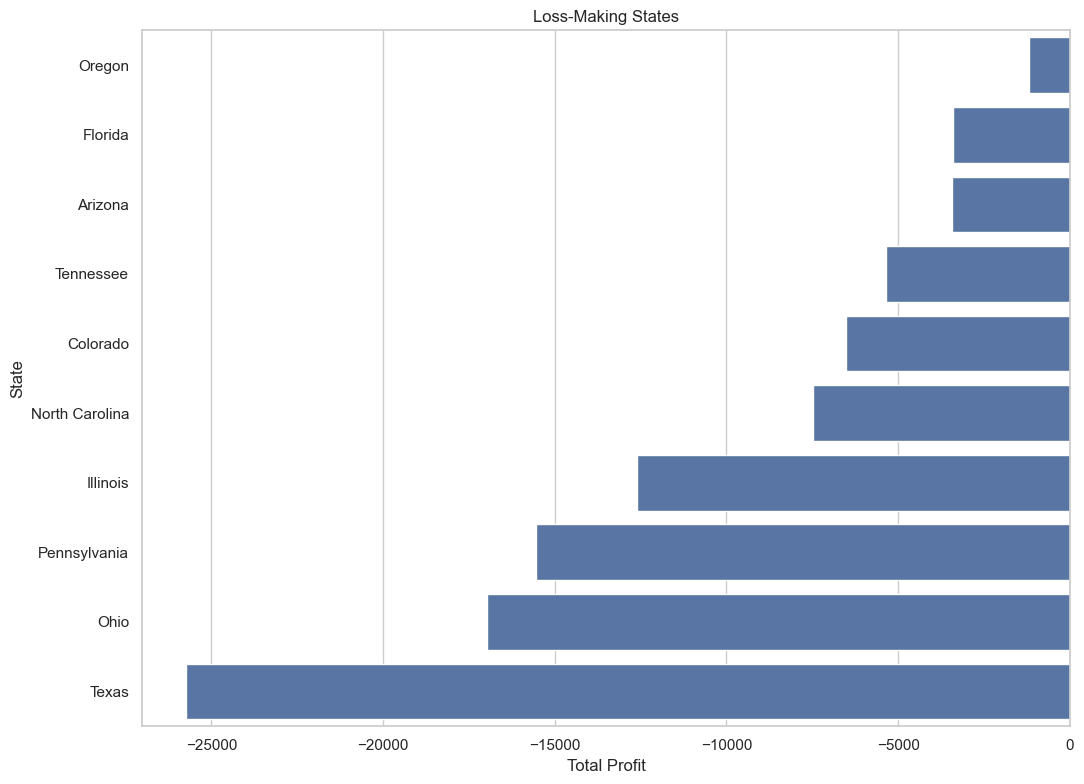

In [23]:
loss_states = state_profit[state_profit["profit"] < 0].copy()

print(f"Loss-making states: {len(loss_states)}")

if loss_states.empty:
    print("No state has an overall negative profit.")
else:
    display(loss_states)
    plt.figure(figsize=(11, 8))
    sns.barplot(data=loss_states, x="profit", y="state")
    plt.title("Loss-Making States")
    plt.xlabel("Total Profit")
    plt.ylabel("State")
    plt.tight_layout()
    plt.show()


## 24. Top 15 Cities by Sales

,city,sales
329,New York City,"256,368.16"
266,Los Angeles,"175,851.34"
452,Seattle,"119,540.74"
438,San Francisco,"112,669.09"
374,Philadelphia,"109,077.01"
207,Houston,"64,504.76"
80,Chicago,"48,539.54"
437,San Diego,"47,521.03"
216,Jacksonville,"44,713.18"
464,Springfield,"43,054.34"


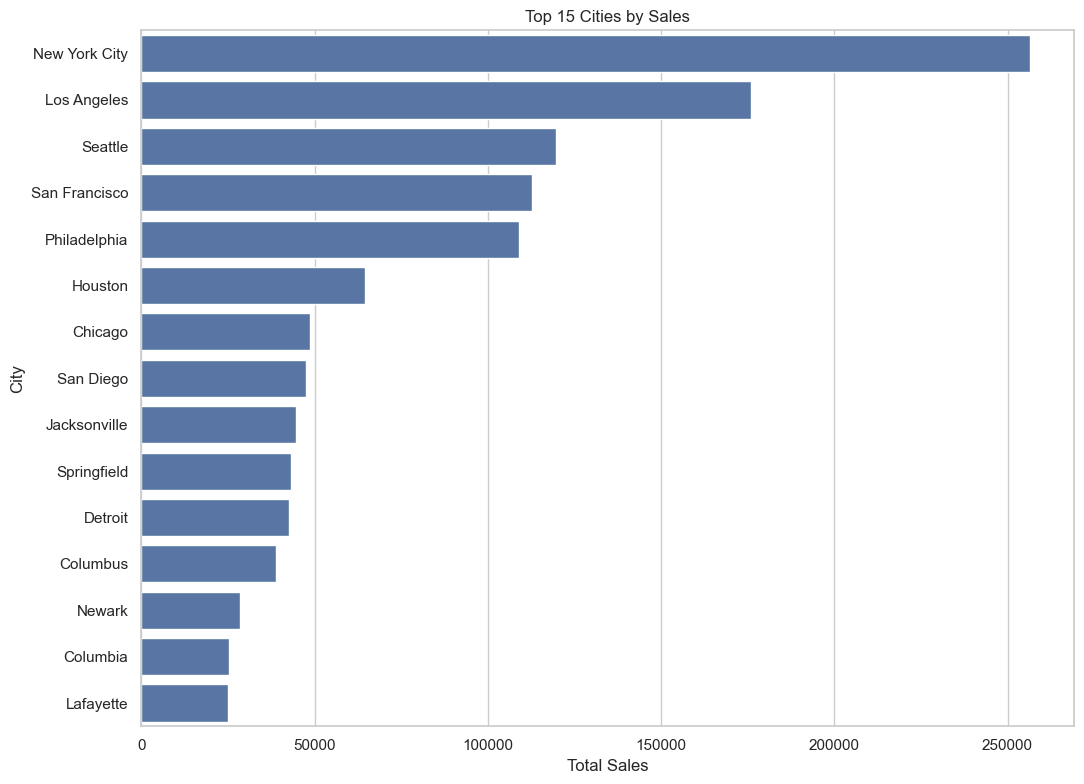

In [24]:
city_sales = (
    df.groupby("city", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=False)
)
display(city_sales.head(15))

plt.figure(figsize=(11, 8))
sns.barplot(data=city_sales.head(15), x="sales", y="city")
plt.title("Top 15 Cities by Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.tight_layout()
plt.show()


## 25. Quantity by Category

,category,quantity
1,Office Supplies,22906
0,Furniture,8028
2,Technology,6939


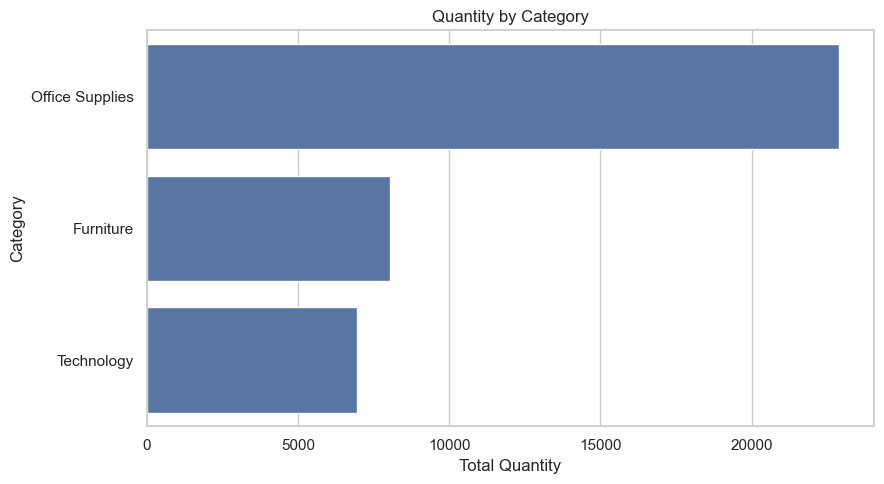

In [25]:
quantity_category = (
    df.groupby("category", as_index=False)["quantity"]
      .sum()
      .sort_values("quantity", ascending=False)
)
display(quantity_category)

plt.figure(figsize=(9, 5))
sns.barplot(data=quantity_category, x="quantity", y="category")
plt.title("Quantity by Category")
plt.xlabel("Total Quantity")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


## 26. Discount Distribution

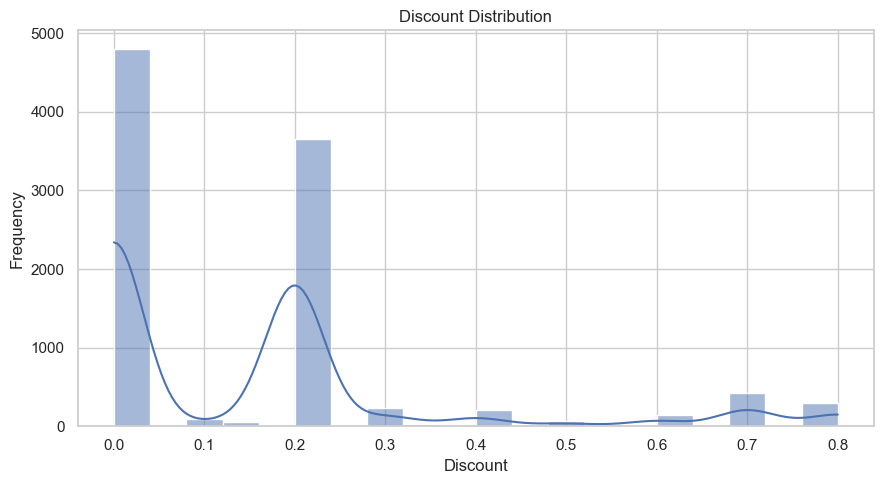

In [26]:
plt.figure(figsize=(9, 5))
sns.histplot(df["discount"], bins=20, kde=True)
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 27. Discount vs Profit

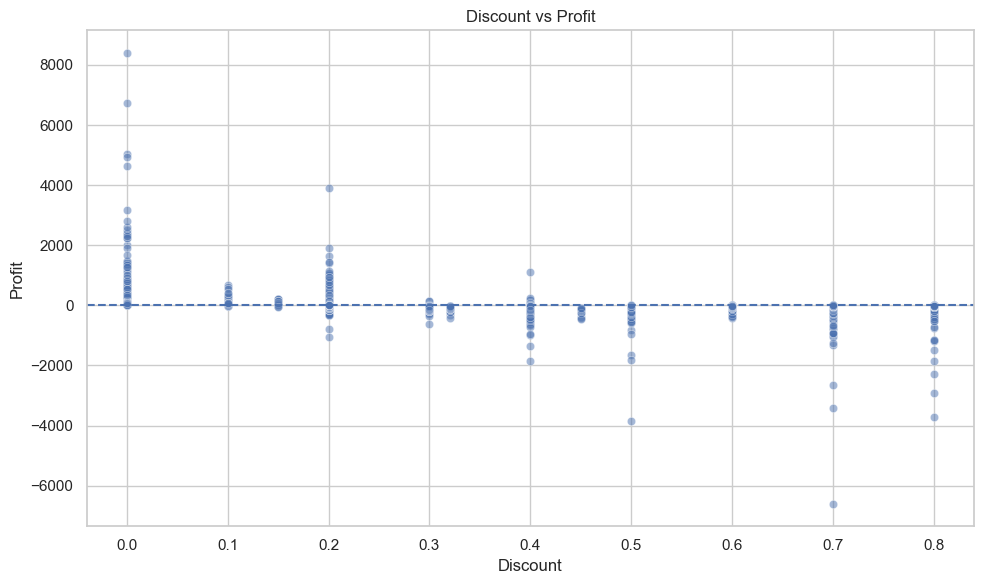

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="discount", y="profit", alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


## 28. Average Profit by Discount Level

,discount,profit
0,0.00,66.90
1,0.10,96.06
2,0.15,27.29
3,0.20,24.70
4,0.30,-45.68
5,0.32,-88.56
6,0.40,-111.93
7,0.45,-226.65
8,0.50,-310.70
9,0.60,-43.08


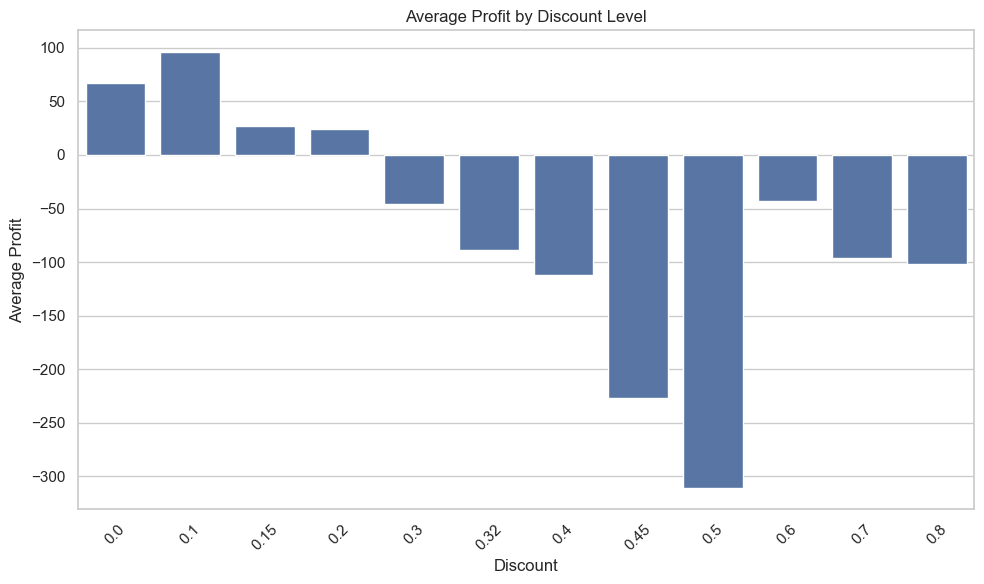

In [28]:
discount_profit = (
    df.groupby("discount", as_index=False)["profit"]
      .mean()
      .sort_values("discount")
)
display(discount_profit)

plt.figure(figsize=(10, 6))
sns.barplot(data=discount_profit, x="discount", y="profit")
plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 29. Sales vs Profit

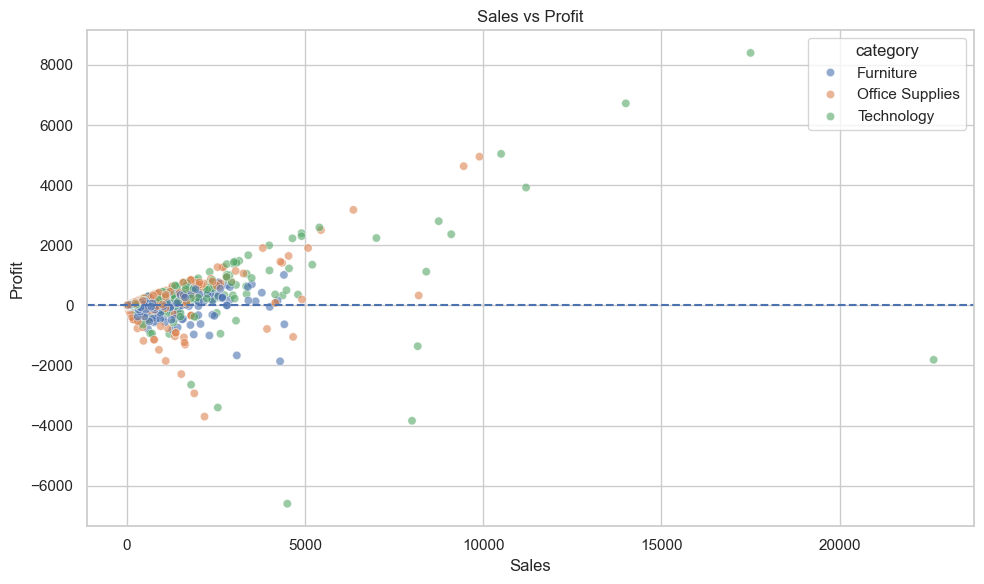

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="sales", y="profit", hue="category", alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


## 30. Correlation Heatmap

,sales,quantity,discount,profit
sales,1.00,0.20,-0.03,0.48
quantity,0.20,1.00,0.01,0.07
discount,-0.03,0.01,1.00,-0.22
profit,0.48,0.07,-0.22,1.00


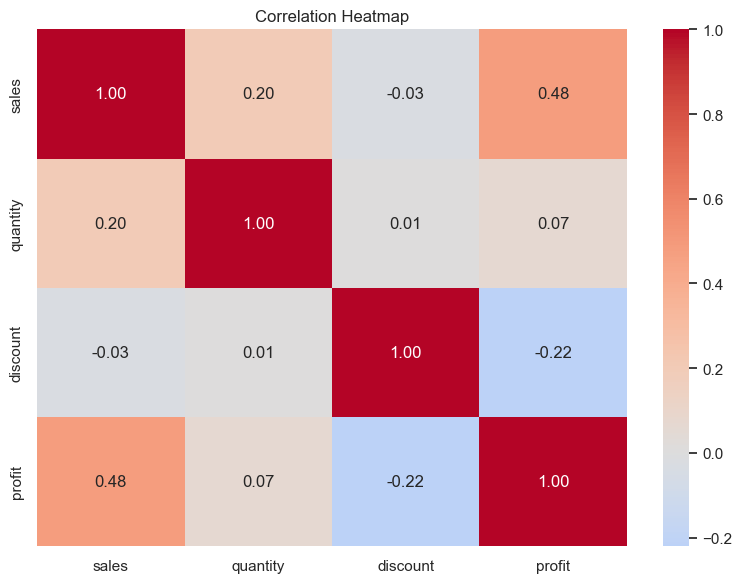

In [30]:
corr_columns = ["sales", "quantity", "discount", "profit"]
corr_matrix = df[corr_columns].corr()
display(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 31. Category × Region Profit Heatmap

region,Central,East,South,West
category,,,,
Furniture,"-2,871.05","3,046.17","6,771.21","11,504.95"
Office Supplies,"8,879.98","41,014.58","19,986.39","52,609.85"
Technology,"33,697.43","47,462.04","19,991.83","44,303.65"


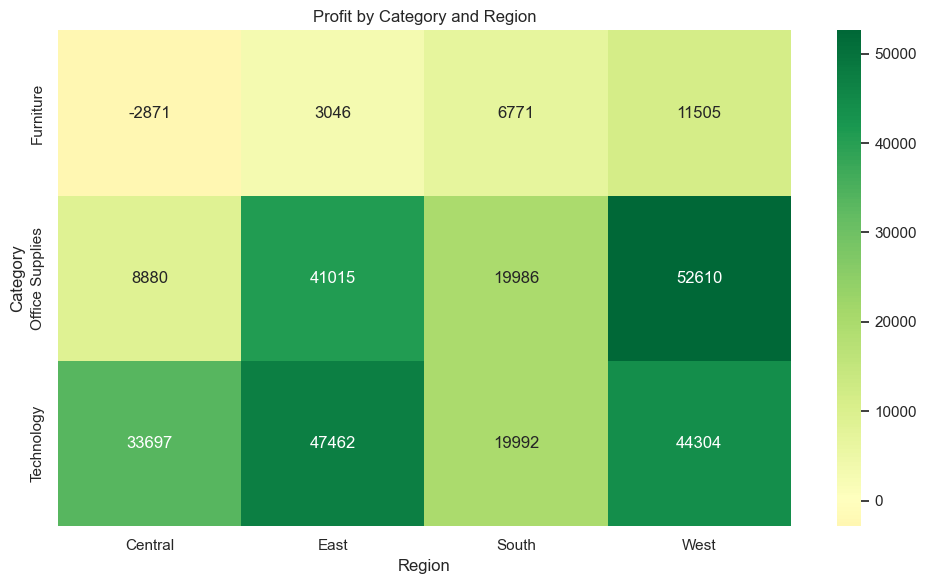

In [31]:
category_region_profit = pd.pivot_table(
    df, index="category", columns="region",
    values="profit", aggfunc="sum", fill_value=0
)
display(category_region_profit)

plt.figure(figsize=(10, 6))
sns.heatmap(category_region_profit, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Profit by Category and Region")
plt.xlabel("Region")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


## 32. Sub-Category × Region Profit Heatmap

region,Central,East,South,West
sub_category,,,,
Accessories,"7,251.63","11,195.86","7,004.54","16,484.60"
Appliances,"-2,638.62","8,391.41","4,123.94","8,261.27"
Art,"1,195.16","1,899.94","1,058.59","2,374.10"
Binders,"-1,043.64","11,267.93","3,900.66","16,096.80"
Bookcases,"-1,997.90","-1,167.63","1,339.49","-1,646.51"
Chairs,"6,592.72","9,357.77","6,612.09","4,027.58"
Copiers,"15,608.84","17,022.84","3,658.91","19,327.24"
Envelopes,"1,777.53","1,812.41","1,465.48","1,908.76"
Fasteners,236.62,263.99,173.72,275.19


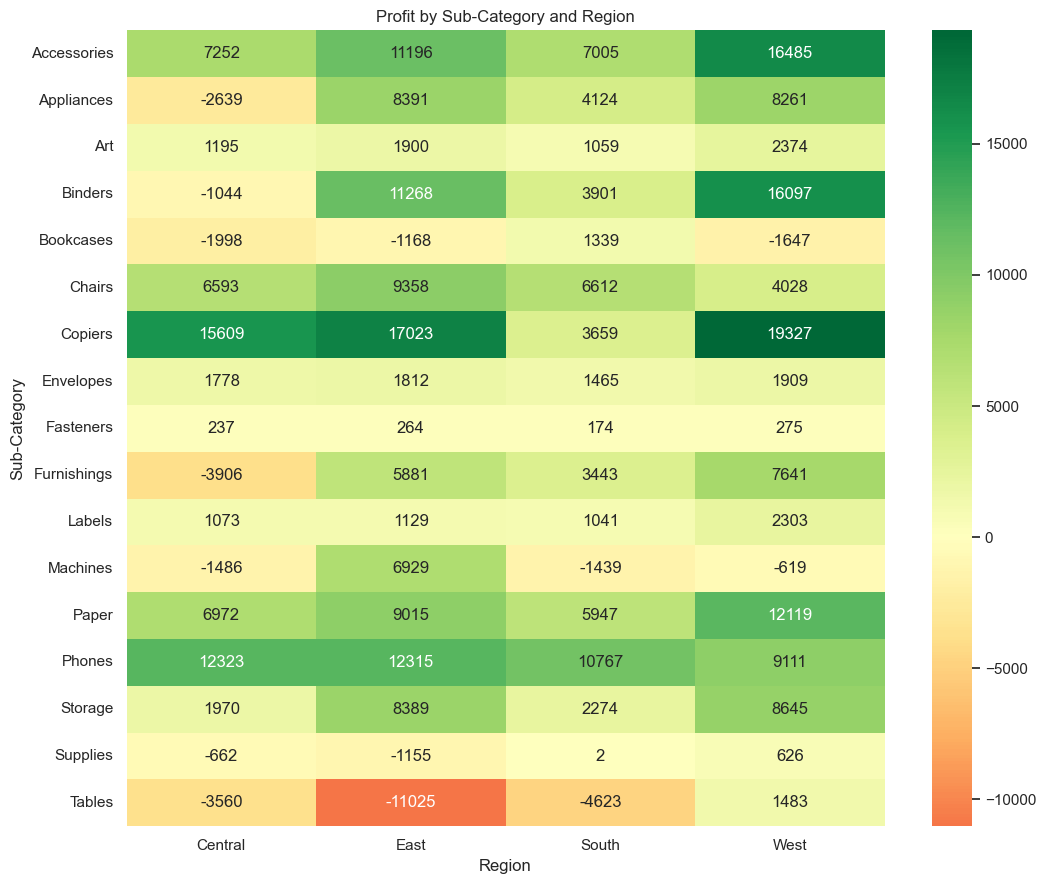

In [32]:
subcategory_region_profit = pd.pivot_table(
    df, index="sub_category", columns="region",
    values="profit", aggfunc="sum", fill_value=0
)
display(subcategory_region_profit)

plt.figure(figsize=(11, 9))
sns.heatmap(subcategory_region_profit, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Profit by Sub-Category and Region")
plt.xlabel("Region")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


# Business Insights & Recommendations

## 33. Best and Worst Performers

In [33]:
best_category_sales = category_sales.iloc[0]
best_category_profit = category_profit.iloc[0]
worst_category_profit = category_profit.iloc[-1]
best_region_profit = region_profit.iloc[0]
worst_region_profit = region_profit.iloc[-1]
best_subcategory_profit = subcategory_profit.iloc[0]
worst_subcategory_profit = subcategory_profit.iloc[-1]

print("Best category by sales:")
print(f"  {best_category_sales['category']} — ${best_category_sales['sales']:,.2f}")

print("\nBest category by profit:")
print(f"  {best_category_profit['category']} — ${best_category_profit['profit']:,.2f}")

print("\nLowest category by profit:")
print(f"  {worst_category_profit['category']} — ${worst_category_profit['profit']:,.2f}")

print("\nBest region by profit:")
print(f"  {best_region_profit['region']} — ${best_region_profit['profit']:,.2f}")

print("\nLowest region by profit:")
print(f"  {worst_region_profit['region']} — ${worst_region_profit['profit']:,.2f}")

print("\nBest sub-category by profit:")
print(f"  {best_subcategory_profit['sub_category']} — ${best_subcategory_profit['total_profit']:,.2f}")

print("\nLowest sub-category by profit:")
print(f"  {worst_subcategory_profit['sub_category']} — ${worst_subcategory_profit['total_profit']:,.2f}")


Best category by sales:
  Technology — $836,154.03

Best category by profit:
  Technology — $145,454.95

Lowest category by profit:
  Furniture — $18,451.27

Best region by profit:
  West — $108,418.45

Lowest region by profit:
  Central — $39,706.36

Best sub-category by profit:
  Copiers — $55,617.82

Lowest sub-category by profit:
  Tables — $-17,725.48


## 34. Automated Business Insights

In [34]:
print("BUSINESS INSIGHTS\n")
print(
    f"1. Total sales are ${total_sales:,.2f}, total profit is "
    f"${total_profit:,.2f}, and profit margin is {profit_margin:.2f}%."
)
print(
    f"2. {best_category_profit['category']} is the most profitable category "
    f"with ${best_category_profit['profit']:,.2f} profit."
)
print(
    f"3. {best_region_profit['region']} is the most profitable region "
    f"with ${best_region_profit['profit']:,.2f} profit."
)

negative_discount_levels = (
    discount_profit[discount_profit["profit"] < 0]["discount"].tolist()
)
if negative_discount_levels:
    print("4. Some discount levels have negative average profit; discount policy should be reviewed.")
else:
    print("4. No discount level has negative average profit in the aggregated analysis.")

if not loss_subcategories.empty:
    print(
        f"5. {len(loss_subcategories)} sub-categories have negative total profit "
        "and should be investigated."
    )
else:
    print(
        "5. No sub-category has negative overall profit, although individual "
        "transactions may still be loss-making."
    )


BUSINESS INSIGHTS

1. Total sales are $2,297,200.86, total profit is $286,397.02, and profit margin is 12.47%.
2. Technology is the most profitable category with $145,454.95 profit.
3. West is the most profitable region with $108,418.45 profit.
4. Some discount levels have negative average profit; discount policy should be reviewed.
5. 3 sub-categories have negative total profit and should be investigated.


## 35. Business Recommendations

In [35]:
recommendations = [
    "Monitor profit and profit margin alongside sales volume.",
    "Review discount levels where average profit declines.",
    "Investigate low-profit sub-categories for pricing, cost, and discount issues.",
    "Use regional profitability to prioritize sales and operational attention.",
    "Separate high-sales/low-profit areas from genuinely healthy performers.",
    "Use the heatmaps to identify category-region combinations requiring attention."
]

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")


1. Monitor profit and profit margin alongside sales volume.
2. Review discount levels where average profit declines.
3. Investigate low-profit sub-categories for pricing, cost, and discount issues.
4. Use regional profitability to prioritize sales and operational attention.
5. Separate high-sales/low-profit areas from genuinely healthy performers.
6. Use the heatmaps to identify category-region combinations requiring attention.


# Final Conclusion

**Raw Data → Cleaning → Validation → EDA → Visualization → KPI Analysis → Business Insights → Recommendations**

This project demonstrates practical Data Analyst skills using the available Superstore fields: sales, quantity, discount, profit, category, sub-category, region, state, city, customer segment, and shipping mode.

The notebook deliberately does **not** invent unsupported order-date, customer-name, product-name, or order-ID analysis when those fields are absent from the dataset.
